# INF280 - Estadística Computacional
## Laboratorio 2

**Grupo 10**

| Integrante | Rol |
|---|---|
| Emilio Araya | Integrante |
| Benjamín Lira | Integrante |
| Nicolás Muñoz | Integrante |
| Jaime Muena | Integrante |

**Universidad Técnica Federico Santa María — Campus San Joaquín**  

---
## Contexto

Trabajamos con el dataset **Health Insurance Cost and Risk** (Kaggle), con 1335 asegurados tras limpieza, que incluye variables demograficas, de estilo de vida y costos medicos facturados (`charges`). La hipotesis del Lab 1 pregunta si existe una diferencia significativa en costos entre fumadores y no fumadores, y si dentro del grupo fumador los costos promedio difieren cuando el BMI supera 30. Este laboratorio aborda esa hipotesis descriptiva mediante estimacion puntual clasica, bootstrap y simulacion Monte Carlo.

---
## Setup: Imports, Configuración Global y Carga de Datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', '{:,.2f}'.format)

In [2]:
df = pd.read_csv('health_insurance_cost_and_risk_dataset.csv')
df['smoker'] = df['smoker'].map({'yes': 'Si', 'no': 'No'})
df_limpio = df.dropna().copy()

print(f"Filas originales : {len(df):,}")
print(f"Filas tras dropna: {len(df_limpio):,}")
print(f"Columnas         : {list(df_limpio.columns)}")

Filas originales : 1,338
Filas tras dropna: 1,335
Columnas         : ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'blood_pressure', 'exercise_frequency', 'pre_existing_condition', 'occupation_risk', 'annual_income']


In [3]:
fumadores    = df_limpio[df_limpio['smoker'] == 'Si']
no_fumadores = df_limpio[df_limpio['smoker'] == 'No']

fum_obeso    = fumadores[fumadores['bmi'] > 30]
fum_no_obeso = fumadores[fumadores['bmi'] <= 30]

resumen_grupos = pd.DataFrame({
    'Grupo': [
        'Total (limpio)',
        'Fumadores',
        'No fumadores',
        'Fumadores con BMI > 30 (obesos)',
        'Fumadores con BMI <= 30 (no obesos)'
    ],
    'n': [
        len(df_limpio),
        len(fumadores),
        len(no_fumadores),
        len(fum_obeso),
        len(fum_no_obeso)
    ]
})
resumen_grupos['%'] = (resumen_grupos['n'] / len(df_limpio) * 100).round(1)

print("Tamanos muestrales por subgrupo:")
print(resumen_grupos.to_string(index=False))

Tamanos muestrales por subgrupo:
                              Grupo    n      %
                     Total (limpio) 1335 100.00
                          Fumadores  273  20.40
                       No fumadores 1062  79.60
    Fumadores con BMI > 30 (obesos)  144  10.80
Fumadores con BMI <= 30 (no obesos)  129   9.70


---
## Sección 1: Estimación Puntual

La hipótesis plantea dos diferencias promedio de interés, formalizadas como diferencias de medias poblacionales:

$$\theta_1 = \mu_{\text{charges} \mid \text{fumador}} - \mu_{\text{charges} \mid \text{no fumador}}$$

$$\theta_2 = \mu_{\text{charges} \mid \text{fumador, BMI} > 30} - \mu_{\text{charges} \mid \text{fumador, BMI} \leq 30}$$

La diferencia de medias es el parámetro pertinente porque la hipótesis pregunta por la **diferencia promedio asociada** al tabaquismo y a la obesidad sobre el costo. Además, la media es el estadístico actuarialmente relevante: el costo total esperado de una cartera es la suma de los costos individuales esperados, por lo que cuantificar $\theta_1$ y $\theta_2$ se traduce directamente en comparaciones de primas esperadas entre subgrupos. En particular, $\theta_2$ mide heterogeneidad de costos dentro de fumadores según BMI; no constituye por sí solo una prueba formal de interacción entre tabaquismo y obesidad, para lo cual se requeriría un modelo con término de interacción.

El estimador $\hat{\theta} = \bar{X}_1 - \bar{X}_2$ tiene tres propiedades que lo justifican. Es **insesgado**: $\mathbb{E}[\hat{\theta}] = \mu_1 - \mu_2 = \theta$ por linealidad de la esperanza. Es **consistente**: por la Ley de los Grandes Números $\hat{\theta} \xrightarrow{P} \theta$ cuando $n \to \infty$. Es **eficiente** asintóticamente: por el TCL, $\sqrt{n}(\hat{\theta} - \theta) \xrightarrow{d} \mathcal{N}(0, \sigma^2)$, y en la clase de estimadores lineales insesgados la diferencia de medias minimiza la varianza asintótica.

In [4]:
def estimacion_clasica(grupo1, grupo2, nombre_param, alpha=0.05):
    n1, n2 = len(grupo1), len(grupo2)
    media1, media2 = grupo1.mean(), grupo2.mean()
    theta_hat = media1 - media2

    var1, var2 = grupo1.var(ddof=1), grupo2.var(ddof=1)
    ee = np.sqrt(var1/n1 + var2/n2)

    gl = (var1/n1 + var2/n2)**2 / ((var1/n1)**2/(n1-1) + (var2/n2)**2/(n2-1))
    t_crit = stats.t.ppf(1 - alpha/2, df=gl)

    ic_inf = theta_hat - t_crit * ee
    ic_sup = theta_hat + t_crit * ee

    return {
        'Parametro': nombre_param,
        'n grupo 1': int(n1),
        'n grupo 2': int(n2),
        'Media grupo 1 ($)': round(media1, 2),
        'Media grupo 2 ($)': round(media2, 2),
        'θ̂ ($)': round(theta_hat, 2),
        'Error Estandar ($)': round(ee, 2),
        'IC 95% inf. ($)': round(ic_inf, 2),
        'IC 95% sup. ($)': round(ic_sup, 2),
    }

resultado_theta1 = estimacion_clasica(
    fumadores['charges'], no_fumadores['charges'],
    'θ1: fumador vs. no fumador'
)
resultado_theta2 = estimacion_clasica(
    fum_obeso['charges'], fum_no_obeso['charges'],
    'θ2: fum. obeso vs. fum. no obeso'
)

tabla_estimacion = pd.DataFrame([resultado_theta1, resultado_theta2])
print("=== Tabla de estimacion puntual clasica ===\n")
display(tabla_estimacion.set_index('Parametro'))

=== Tabla de estimacion puntual clasica ===



,n grupo 1,n grupo 2,Media grupo 1 ($),Media grupo 2 ($),θ̂ ($),Error Estandar ($),IC 95% inf. ($),IC 95% sup. ($)
Parametro,,,,,,,,
θ1: fumador vs. no fumador,273,1062,"32,060.89","8,421.20","23,639.69",723.26,"22,216.58","25,062.80"
θ2: fum. obeso vs. fum. no obeso,144,129,"41,692.81","21,308.97","20,383.83",656.75,"19,090.84","21,676.83"


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_16424\742404754.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='smoker', y='charges', palette='Set1',
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_16424\742404754.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fum_plot, x='Obesidad', y='charges', palette='Set2', ax=ax2)


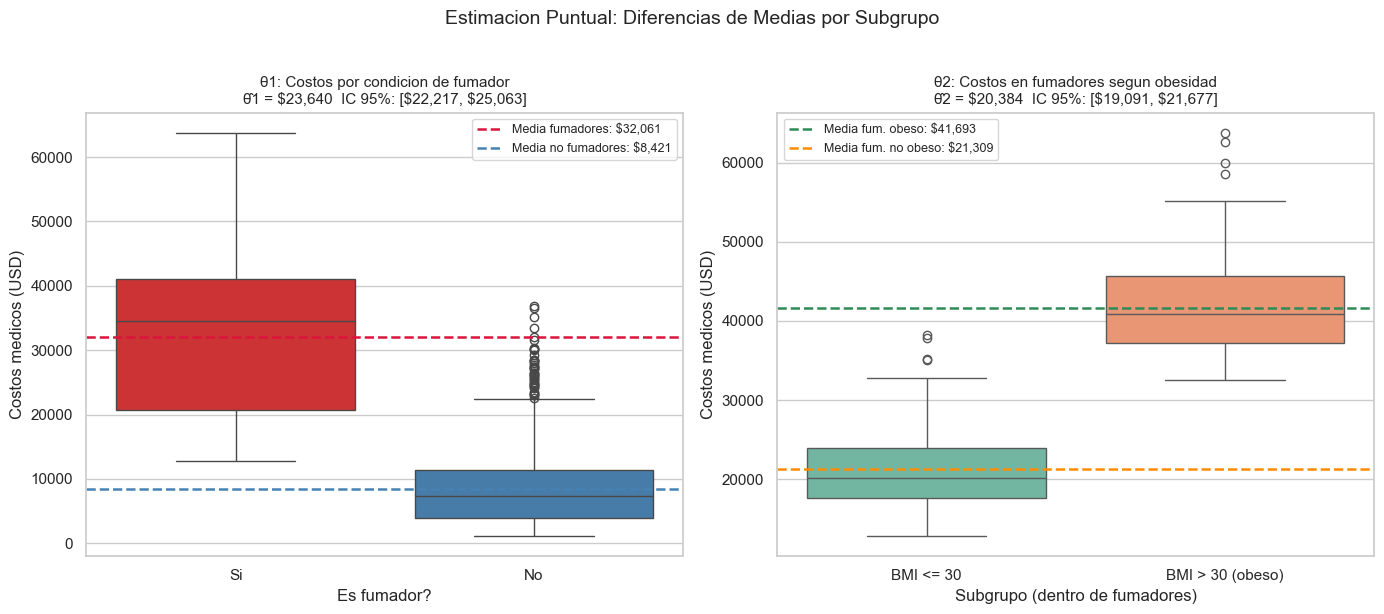

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
sns.boxplot(data=df_limpio, x='smoker', y='charges', palette='Set1',
            order=['Si', 'No'], ax=ax1)
media_fum   = fumadores['charges'].mean()
media_nofum = no_fumadores['charges'].mean()
ax1.axhline(media_fum,   color='crimson',   linestyle='--', linewidth=1.8,
            label=f'Media fumadores: ${media_fum:,.0f}')
ax1.axhline(media_nofum, color='steelblue', linestyle='--', linewidth=1.8,
            label=f'Media no fumadores: ${media_nofum:,.0f}')
ax1.set_title(
    f'θ1: Costos por condicion de fumador\n'
    f'θ̂1 = ${resultado_theta1["θ̂ ($)"]:,.0f}  '
    f'IC 95%: [${resultado_theta1["IC 95% inf. ($)"]:,.0f}, ${resultado_theta1["IC 95% sup. ($)"]:,.0f}]',
    fontsize=11)
ax1.set_xlabel('Es fumador?')
ax1.set_ylabel('Costos medicos (USD)')
ax1.legend(fontsize=9)

ax2 = axes[1]
fum_plot = fumadores.copy()
fum_plot['Obesidad'] = fum_plot['bmi'].apply(
    lambda x: 'BMI > 30 (obeso)' if x > 30 else 'BMI <= 30')
sns.boxplot(data=fum_plot, x='Obesidad', y='charges', palette='Set2', ax=ax2)
media_fo  = fum_obeso['charges'].mean()
media_fno = fum_no_obeso['charges'].mean()
ax2.axhline(media_fo,  color='seagreen',   linestyle='--', linewidth=1.8,
            label=f'Media fum. obeso: ${media_fo:,.0f}')
ax2.axhline(media_fno, color='darkorange', linestyle='--', linewidth=1.8,
            label=f'Media fum. no obeso: ${media_fno:,.0f}')
ax2.set_title(
    f'θ2: Costos en fumadores segun obesidad\n'
    f'θ̂2 = ${resultado_theta2["θ̂ ($)"]:,.0f}  '
    f'IC 95%: [${resultado_theta2["IC 95% inf. ($)"]:,.0f}, ${resultado_theta2["IC 95% sup. ($)"]:,.0f}]',
    fontsize=11)
ax2.set_xlabel('Subgrupo (dentro de fumadores)')
ax2.set_ylabel('Costos medicos (USD)')
ax2.legend(fontsize=9)

plt.suptitle('Estimacion Puntual: Diferencias de Medias por Subgrupo', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_estimacion_puntual.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 2: Bootstrap

El bootstrap (Efron, 1979) es un método de remuestreo que construye la distribución muestral de un estimador usando solo los datos disponibles, sin supuestos distribucionales sobre la población.

**Algoritmo (método percentil):**

1. Tomar la muestra original $\mathbf{X} = (X_1, \dots, X_n)$ como proxy de la distribución poblacional.
2. Generar $B$ muestras bootstrap $\mathbf{X}^*_b$ de tamaño $n$ con reemplazo de $\mathbf{X}$.
3. Calcular el estadístico $\hat{\theta}^*_b$ sobre cada $\mathbf{X}^*_b$.
4. El IC percentil al 95% es $\left[\hat{\theta}^*_{(0.025)},\ \hat{\theta}^*_{(0.975)}\right]$; el sesgo se estima como $\bar{\theta}^* - \hat{\theta}$.

In [6]:
def bootstrap_diferencia_medias(group1, group2, B=10000, seed=42):
    rng = np.random.default_rng(seed)
    x, y = group1.values, group2.values
    n_x, n_y = len(x), len(y)

    idx_x = rng.integers(0, n_x, size=(B, n_x))
    idx_y = rng.integers(0, n_y, size=(B, n_y))

    medias_x = x[idx_x].mean(axis=1)
    medias_y = y[idx_y].mean(axis=1)

    return medias_x - medias_y


B = 10_000
theta1_boot = bootstrap_diferencia_medias(fumadores['charges'], no_fumadores['charges'], B=B)
theta2_boot = bootstrap_diferencia_medias(fum_obeso['charges'], fum_no_obeso['charges'], B=B)

ic_theta1_boot = np.percentile(theta1_boot, [2.5, 97.5])
ic_theta2_boot = np.percentile(theta2_boot, [2.5, 97.5])

sesgo_theta1 = theta1_boot.mean() - resultado_theta1['θ̂ ($)']
sesgo_theta2 = theta2_boot.mean() - resultado_theta2['θ̂ ($)']

print(f"=== BOOTSTRAP (B = {B:,} replicas) ===")
print(f"\nθ1 (fumador vs. no fumador):")
print(f"  Estimador puntual θ̂1        : ${resultado_theta1['θ̂ ($)']:,.2f}")
print(f"  Media bootstrap θ̄*1          : ${theta1_boot.mean():,.2f}")
print(f"  Sesgo bootstrap (θ̄* - θ̂)    : ${sesgo_theta1:+,.2f}  <- practicamente insesgado")
print(f"  EE bootstrap (SD replicas)   : ${theta1_boot.std():,.2f}")
print(f"  IC percentil 95%             : [${ic_theta1_boot[0]:,.2f}, ${ic_theta1_boot[1]:,.2f}]")

print(f"\nθ2 (fum. obeso vs. fum. no obeso):")
print(f"  Estimador puntual θ̂2        : ${resultado_theta2['θ̂ ($)']:,.2f}")
print(f"  Media bootstrap θ̄*2          : ${theta2_boot.mean():,.2f}")
print(f"  Sesgo bootstrap (θ̄* - θ̂)    : ${sesgo_theta2:+,.2f}  <- practicamente insesgado")
print(f"  EE bootstrap (SD replicas)   : ${theta2_boot.std():,.2f}")
print(f"  IC percentil 95%             : [${ic_theta2_boot[0]:,.2f}, ${ic_theta2_boot[1]:,.2f}]")

=== BOOTSTRAP (B = 10,000 replicas) ===

θ1 (fumador vs. no fumador):
  Estimador puntual θ̂1        : $23,639.69
  Media bootstrap θ̄*1          : $23,645.02
  Sesgo bootstrap (θ̄* - θ̂)    : $+5.33  <- practicamente insesgado
  EE bootstrap (SD replicas)   : $725.14
  IC percentil 95%             : [$22,235.62, $25,082.42]

θ2 (fum. obeso vs. fum. no obeso):
  Estimador puntual θ̂2        : $20,383.83
  Media bootstrap θ̄*2          : $20,389.57
  Sesgo bootstrap (θ̄* - θ̂)    : $+5.74  <- practicamente insesgado
  EE bootstrap (SD replicas)   : $659.59
  IC percentil 95%             : [$19,099.54, $21,671.27]


### Distribuciones Bootstrap e Intervalos de Confianza

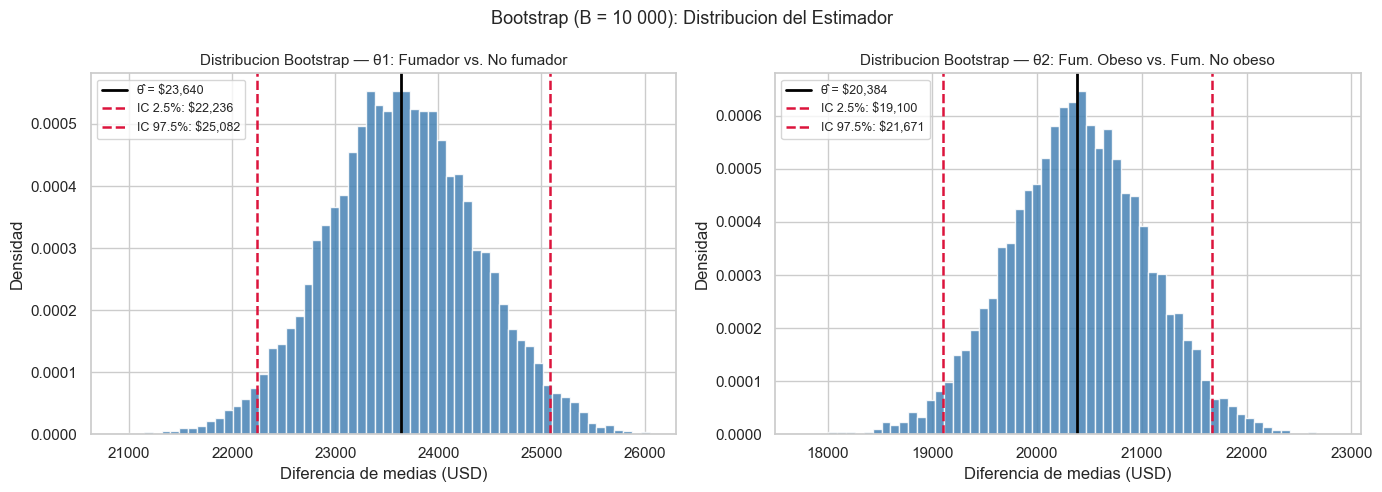

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, boot, ic, theta_hat, titulo in zip(
    axes,
    [theta1_boot, theta2_boot],
    [ic_theta1_boot, ic_theta2_boot],
    [resultado_theta1['θ̂ ($)'], resultado_theta2['θ̂ ($)']],
    ['θ1: Fumador vs. No fumador', 'θ2: Fum. Obeso vs. Fum. No obeso']
):
    ax.hist(boot, bins=60, color='steelblue', edgecolor='white', alpha=0.85, density=True)
    ax.axvline(theta_hat, color='black',   linestyle='-',  linewidth=2,   label=f'θ̂ = ${theta_hat:,.0f}')
    ax.axvline(ic[0],     color='crimson', linestyle='--', linewidth=1.8, label=f'IC 2.5%: ${ic[0]:,.0f}')
    ax.axvline(ic[1],     color='crimson', linestyle='--', linewidth=1.8, label=f'IC 97.5%: ${ic[1]:,.0f}')
    ax.set_title(f'Distribucion Bootstrap — {titulo}', fontsize=11)
    ax.set_xlabel('Diferencia de medias (USD)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

plt.suptitle('Bootstrap (B = 10 000): Distribucion del Estimador', fontsize=13)
plt.tight_layout()
plt.savefig('fig_bootstrap_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

### Convergencia del Bootstrap

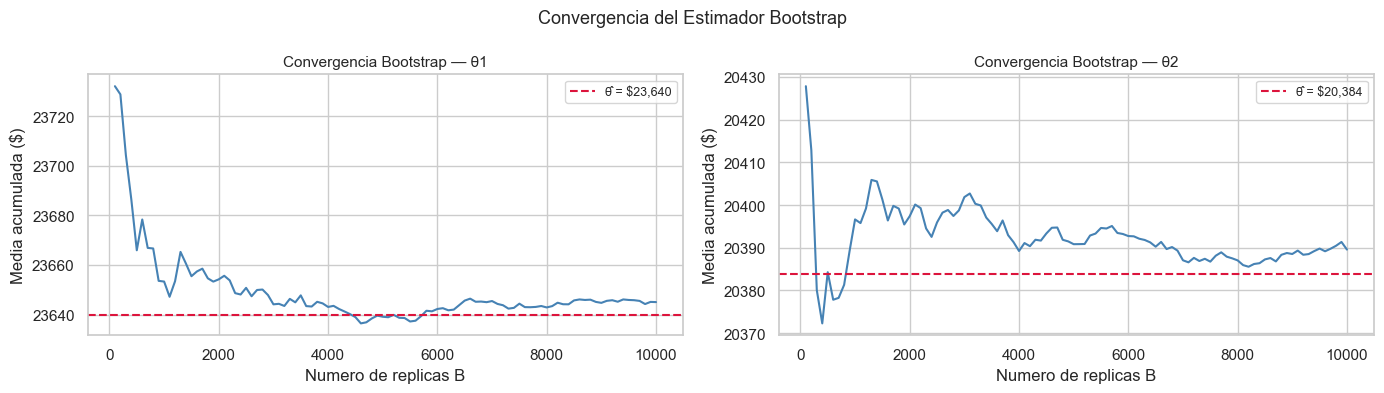

In [8]:
checkpoints = np.arange(100, len(theta1_boot) + 1, 100)

medias_acum_t1 = [theta1_boot[:k].mean() for k in checkpoints]
medias_acum_t2 = [theta2_boot[:k].mean() for k in checkpoints]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, medias_acum, theta_hat, titulo in zip(
    axes,
    [medias_acum_t1, medias_acum_t2],
    [resultado_theta1['θ̂ ($)'], resultado_theta2['θ̂ ($)']],
    ['θ1', 'θ2']
):
    ax.plot(checkpoints, medias_acum, color='steelblue', linewidth=1.5)
    ax.axhline(theta_hat, color='crimson', linestyle='--', linewidth=1.5,
               label=f'θ̂ = ${theta_hat:,.0f}')
    ax.set_title(f'Convergencia Bootstrap — {titulo}', fontsize=11)
    ax.set_xlabel('Numero de replicas B')
    ax.set_ylabel('Media acumulada ($)')
    ax.legend(fontsize=9)

plt.suptitle('Convergencia del Estimador Bootstrap', fontsize=13)
plt.tight_layout()
plt.savefig('fig_bootstrap_convergencia.png', dpi=150, bbox_inches='tight')
plt.show()

Ambos métodos entregan estimaciones prácticamente idénticas: las diferencias en estimación puntual, error estándar e IC son menores al 0.3%. Dado que los tamaños muestrales son relativamente grandes ($n_1 = 273$ y $n_2 = 1062$), la aproximación normal usada por Welch parece razonable para $\hat{\theta}$. La similitud con el bootstrap sugiere que, en esta muestra, ambos métodos capturan una incertidumbre muy parecida.

El bootstrap agrega valor en tres aspectos concretos: no requiere que los datos individuales sean normales (solo que la media lo sea asintóticamente), estima el sesgo empíricamente sin derivación analítica ($|\hat{B}| < \$6$ en ambos parámetros, lo que sugiere un sesgo bootstrap muy pequeño), y es directamente aplicable a cualquier estadístico —mediana, percentiles, razones— sin modificar el código. La limitación central es que hereda el sesgo de la muestra: si la muestra no es representativa, el bootstrap tampoco lo será. El IC percentil también puede sub-cubrir para distribuciones muy asimétricas; variantes como el $\text{BC}_a$ corrigen esto a costa de mayor complejidad.

In [9]:
comparacion = pd.DataFrame([
    {
        'Parametro': 'θ1 (fumador vs. no fumador)',
        'Metodo': 'Clasico (Welch)',
        'Estimacion ($)': resultado_theta1['θ̂ ($)'],
        'EE ($)': resultado_theta1['Error Estandar ($)'],
        'IC 95% inf. ($)': resultado_theta1['IC 95% inf. ($)'],
        'IC 95% sup. ($)': resultado_theta1['IC 95% sup. ($)'],
    },
    {
        'Parametro': 'θ1 (fumador vs. no fumador)',
        'Metodo': 'Bootstrap (percentil)',
        'Estimacion ($)': round(theta1_boot.mean(), 2),
        'EE ($)': round(theta1_boot.std(), 2),
        'IC 95% inf. ($)': round(ic_theta1_boot[0], 2),
        'IC 95% sup. ($)': round(ic_theta1_boot[1], 2),
    },
    {
        'Parametro': 'θ2 (fum. obeso vs. no obeso)',
        'Metodo': 'Clasico (Welch)',
        'Estimacion ($)': resultado_theta2['θ̂ ($)'],
        'EE ($)': resultado_theta2['Error Estandar ($)'],
        'IC 95% inf. ($)': resultado_theta2['IC 95% inf. ($)'],
        'IC 95% sup. ($)': resultado_theta2['IC 95% sup. ($)'],
    },
    {
        'Parametro': 'θ2 (fum. obeso vs. no obeso)',
        'Metodo': 'Bootstrap (percentil)',
        'Estimacion ($)': round(theta2_boot.mean(), 2),
        'EE ($)': round(theta2_boot.std(), 2),
        'IC 95% inf. ($)': round(ic_theta2_boot[0], 2),
        'IC 95% sup. ($)': round(ic_theta2_boot[1], 2),
    },
])

print("=== TABLA COMPARATIVA: CLASICO vs. BOOTSTRAP ===\n")
display(comparacion.set_index(['Parametro', 'Metodo']))

=== TABLA COMPARATIVA: CLASICO vs. BOOTSTRAP ===



Estimacion ($)  EE ($)  \
Parametro                    Metodo                                          
θ1 (fumador vs. no fumador)  Clasico (Welch)             23,639.69  723.26   
                             Bootstrap (percentil)       23,645.02  725.14   
θ2 (fum. obeso vs. no obeso) Clasico (Welch)             20,383.83  656.75   
                             Bootstrap (percentil)       20,389.57  659.59   

                                                    IC 95% inf. ($)  \
Parametro                    Metodo                                   
θ1 (fumador vs. no fumador)  Clasico (Welch)              22,216.58   
                             Bootstrap (percentil)        22,235.62   
θ2 (fum. obeso vs. no obeso) Clasico (Welch)              19,090.84   
                             Bootstrap (percentil)        19,099.54   

                                                    IC 95% sup. ($)  
Parametro                    Metodo                                  
θ1 (fumador vs. no fumador)  Clasico (Welch)              25,062.80  
                             Bootstrap (percentil)        25,082.42  
θ2 (fum. obeso vs. no obeso) Clasico (Welch)              21,676.83  
                             Bootstrap (percentil)        21,671.27

---
## Sección 3: Simulación Monte Carlo

Monte Carlo estima distribuciones de cantidades aleatorias complejas generando miles de realizaciones de un modelo probabilístico. Por la Ley de los Grandes Números, el promedio de los resultados converge al valor esperado verdadero cuando $M \to \infty$.

**Situación de interés:** una aseguradora quiere estimar el costo total anual de una cartera de $N = 1000$ asegurados bajo distintas prevalencias de tabaquismo ($p_F \in \{0.15, 0.20, 0.25\}$). Esto permite cuantificar la diferencia económica esperada a escala de cartera usando las diferencias promedio estimadas en la Sección 1.

**Variables y supuestos del modelo:**

| Variable | Distribución | Parámetros |
|---|---|---|
| $\mathbf{1}_{\text{fumador}_i}$ | Bernoulli($p_F$) | $p_F \in \{0.15, 0.20, 0.25\}$ |
| $\mathbf{1}_{\text{obeso}_i \mid \text{fumador}}$ | Bernoulli($p_{O \mid F}$) | $p_{O \mid F} \approx 0.527$ (obesidad dentro de fumadores) |
| $C_i$ por subgrupo | LogNormal($\mu_k$, $\sigma_k$) | estimados por MLE del dataset |

Supuestos: (1) costos independientes entre asegurados; (2) distribución log-normal por subgrupo, evaluada visualmente con QQ-plots; (3) $p_{O \mid F}$ fija e igual a la observada en el dataset, aplicada solo a fumadores.

**Mecanismo (una réplica):** para cada asegurado $i$, sortear $F_i \sim \text{Bernoulli}(p_F)$; si es fumador, sortear $O_i \sim \text{Bernoulli}(p_{O \mid F})$; generar $C_i$ desde la log-normal de su subgrupo; sumar $S_m = \sum_i C_i$.

In [10]:
log_fo  = np.log(fum_obeso['charges'])
log_fno = np.log(fum_no_obeso['charges'])
log_nf  = np.log(no_fumadores['charges'])

params_log = {
    'fumador_obeso'   : (log_fo.mean(),  log_fo.std(ddof=0)),
    'fumador_no_obeso': (log_fno.mean(), log_fno.std(ddof=0)),
    'no_fumador'      : (log_nf.mean(),  log_nf.std(ddof=0)),
}

p_F_obs    = len(fumadores) / len(df_limpio)
p_O_dado_F = len(fum_obeso) / len(fumadores)

print("=== PARAMETROS LOG-NORMAL ESTIMADOS (MLE) ===")
print(f"{'Subgrupo':25s}  {'mu (log)':>8}  {'sigma (log)':>11}  {'E[C] teorico':>14}  {'Media observada':>16}")
for grupo, (mu, sigma) in params_log.items():
    e_c = np.exp(mu + sigma**2 / 2)
    obs = {'fumador_obeso': fum_obeso, 'fumador_no_obeso': fum_no_obeso, 'no_fumador': no_fumadores}
    print(f"{grupo:25s}  {mu:>8.4f}  {sigma:>11.4f}  ${e_c:>13,.0f}  ${obs[grupo]['charges'].mean():>15,.0f}")

print(f"\nPrevalencias:")
print(f"  Fumadores en el total      : {p_F_obs:.3f}  ({len(fumadores)}/{len(df_limpio)})")
print(f"  Obesos dado fumador (p_O|F): {p_O_dado_F:.3f}  ({len(fum_obeso)}/{len(fumadores)})")

=== PARAMETROS LOG-NORMAL ESTIMADOS (MLE) ===
Subgrupo                   mu (log)  sigma (log)    E[C] teorico   Media observada
fumador_obeso               10.6290       0.1331  $       41,683  $         41,693
fumador_no_obeso             9.9416       0.2210  $       21,292  $         21,309
no_fumador                   8.7880       0.7422  $        8,634  $          8,421

Prevalencias:
  Fumadores en el total      : 0.204  (273/1335)
  Obesos dado fumador (p_O|F): 0.527  (144/273)


### 3.3 Estimación de parámetros log-normales (MLE)


### 3.2 Evaluación visual del supuesto log-normal (QQ-plots)

Antes de usar la distribución log-normal como modelo generativo, evaluamos visualmente si $\log(C_i)$ se aproxima a una distribución normal en cada subgrupo. Si los puntos siguen razonablemente la línea de referencia en el QQ-plot, el supuesto log-normal es plausible para la simulación; esto no constituye una prueba formal de normalidad.

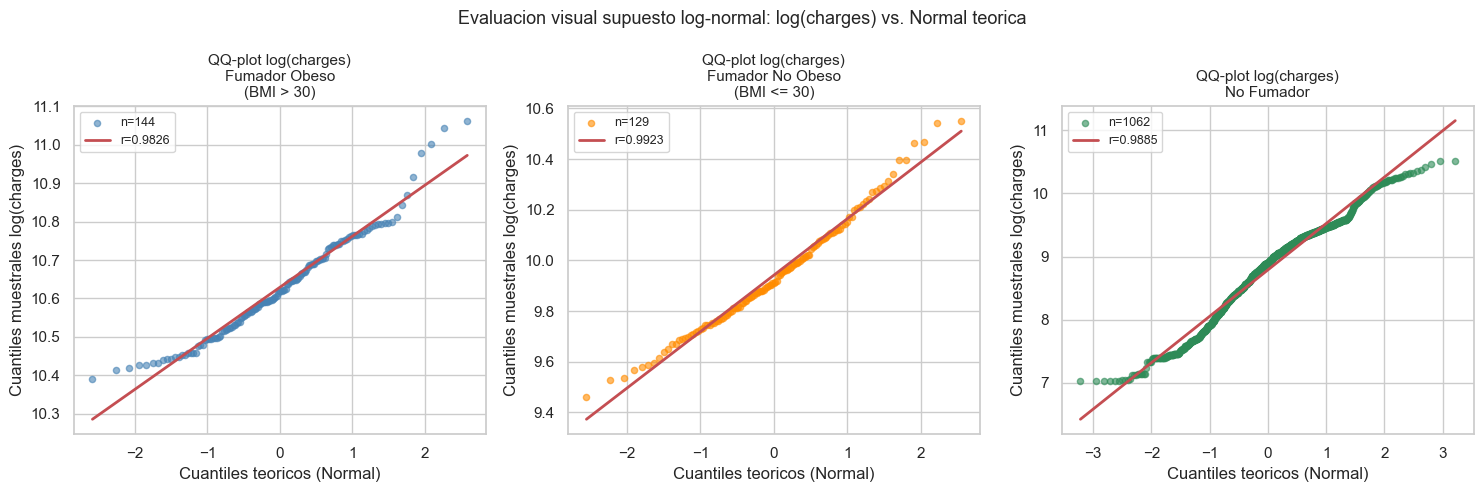

Coeficientes de correlacion r en QQ-plots:
  Fumador Obeso (BMI > 30)      : r = 0.9826
  Fumador No Obeso (BMI <= 30)  : r = 0.9923
  No Fumador                    : r = 0.9885


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

subgrupos = [
    (log_fo,  'Fumador Obeso\n(BMI > 30)',    'steelblue'),
    (log_fno, 'Fumador No Obeso\n(BMI <= 30)', 'darkorange'),
    (log_nf,  'No Fumador',                    'seagreen'),
]

for ax, (log_data, titulo, color) in zip(axes, subgrupos):
    (osm, osr), (slope, intercept, r) = stats.probplot(log_data, dist='norm')
    ax.scatter(osm, osr, alpha=0.6, s=20, color=color, label=f'n={len(log_data)}')
    x_line = np.array([osm.min(), osm.max()])
    ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2, label=f'r={r:.4f}')
    ax.set_title(f'QQ-plot log(charges)\n{titulo}', fontsize=11)
    ax.set_xlabel('Cuantiles teoricos (Normal)')
    ax.set_ylabel('Cuantiles muestrales log(charges)')
    ax.legend(fontsize=9)

plt.suptitle('Evaluacion visual supuesto log-normal: log(charges) vs. Normal teorica', fontsize=13)
plt.tight_layout()
plt.savefig('fig_qqplots_lognormal.png', dpi=150, bbox_inches='tight')
plt.show()

print("Coeficientes de correlacion r en QQ-plots:")
for log_data, titulo, _ in subgrupos:
    _, (_, _, r) = stats.probplot(log_data, dist='norm')
    titulo_corto = titulo.replace('\n', ' ')
    print(f"  {titulo_corto:30s}: r = {r:.4f}")

**Interpretación de los QQ-plots:** Los tres subgrupos muestran una alineación razonablemente cercana con la línea normal teórica, con coeficientes de correlación altos en los QQ-plots ($r$ entre 0.9826 y 0.9923). Esto apoya visualmente el uso de una distribución log-normal como aproximación para modelar los costos dentro de cada subgrupo. Aun así, el supuesto debe tratarse como una simplificación del modelo: los QQ-plots no son una prueba formal de normalidad y el subgrupo no-fumadores presenta leves desviaciones en las colas extremas, esperables al ser un grupo más heterogéneo.

### 3.4 Función de simulación vectorizada

La función `simular_cartera` está completamente vectorizada con NumPy: genera simultáneamente todos los estados ($F_i$, $O_i$) y todos los costos individuales de una cartera, sin bucle Python interno. Esto permite ejecutar $M = 10\,000$ réplicas en tiempo razonable.

In [12]:
def simular_cartera(N, p_F, p_O, params_log, rng):
    es_fumador = rng.random(N) < p_F
    es_obeso   = rng.random(N) < p_O

    mu_fo,  s_fo  = params_log['fumador_obeso']
    mu_fno, s_fno = params_log['fumador_no_obeso']
    mu_nf,  s_nf  = params_log['no_fumador']

    costs_fo  = np.exp(rng.normal(mu_fo,  s_fo,  N))
    costs_fno = np.exp(rng.normal(mu_fno, s_fno, N))
    costs_nf  = np.exp(rng.normal(mu_nf,  s_nf,  N))

    charges = np.where(
        es_fumador & es_obeso, costs_fo,
        np.where(es_fumador,   costs_fno, costs_nf)
    )
    return charges.sum()


def monte_carlo_cartera(N, p_F, p_O, params_log, M=10000, seed=42):
    rng = np.random.default_rng(seed)
    return np.array([simular_cartera(N, p_F, p_O, params_log, rng) for _ in range(M)])


print("Funciones definidas")

Funciones definidas


### Escenarios de prevalencia de tabaquismo

$M = 10.000$ réplicas es una elección razonable para este análisis: la media acumulada se estabiliza visualmente antes de $M = 3.000$ en los tres escenarios, y el error Monte Carlo estándar de la media se calcula como $\widehat{\sigma}_S / \sqrt{M} = 0.01\widehat{\sigma}_S$. En la celda siguiente se reporta este error por escenario para cuantificar la precisión numérica de la simulación.

In [13]:
M = 10_000
N = 1_000
p_O = p_O_dado_F

escenarios = {
    'Escenario 15% fumadores': 0.15,
    'Escenario 20% fumadores': 0.20,
    'Escenario 25% fumadores': 0.25,
}

resultados_mc = {}
for nombre, p_F in escenarios.items():
    resultados_mc[nombre] = monte_carlo_cartera(N, p_F, p_O, params_log, M=M, seed=42)
    media = resultados_mc[nombre].mean()
    p5, p95 = np.percentile(resultados_mc[nombre], [5, 95])
    mcse = resultados_mc[nombre].std(ddof=1) / np.sqrt(M)
    print(f"{nombre}: media = ${media:>14,.0f}  |  P5-P95 = [${p5:,.0f}, ${p95:,.0f}]  |  MCSE media = ${mcse:,.0f}")

print(f"\nSimulacion completada: M={M:,} replicas x 3 escenarios")

Escenario 15% fumadores: media = $    12,145,384  |  P5-P95 = [$11,556,815, $12,754,703]  |  MCSE media = $3,665


Escenario 20% fumadores: media = $    13,315,998  |  P5-P95 = [$12,665,830, $13,970,508]  |  MCSE media = $3,962


Escenario 25% fumadores: media = $    14,488,601  |  P5-P95 = [$13,792,193, $15,177,358]  |  MCSE media = $4,222

Simulacion completada: M=10,000 replicas x 3 escenarios


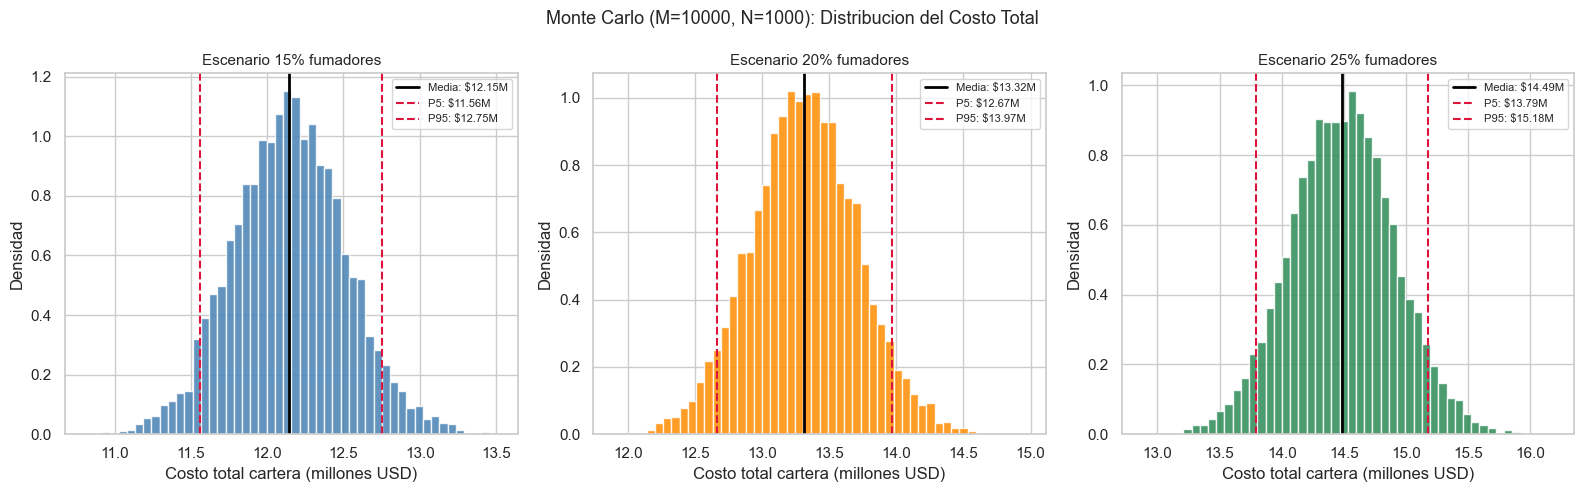

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colores = ['steelblue', 'darkorange', 'seagreen']

for ax, (nombre, costos), color in zip(axes, resultados_mc.items(), colores):
    ax.hist(costos / 1e6, bins=50, color=color, edgecolor='white', alpha=0.85, density=True)
    media = costos.mean()
    p5, p95 = np.percentile(costos, [5, 95])
    ax.axvline(media / 1e6, color='black',   linestyle='-',  linewidth=2,
               label=f'Media: ${media/1e6:.2f}M')
    ax.axvline(p5  / 1e6,  color='crimson', linestyle='--', linewidth=1.5,
               label=f'P5: ${p5/1e6:.2f}M')
    ax.axvline(p95 / 1e6,  color='crimson', linestyle='--', linewidth=1.5,
               label=f'P95: ${p95/1e6:.2f}M')
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel('Costo total cartera (millones USD)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.suptitle(f'Monte Carlo (M={M}, N={N}): Distribucion del Costo Total', fontsize=13)
plt.tight_layout()
plt.savefig('fig_mc_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

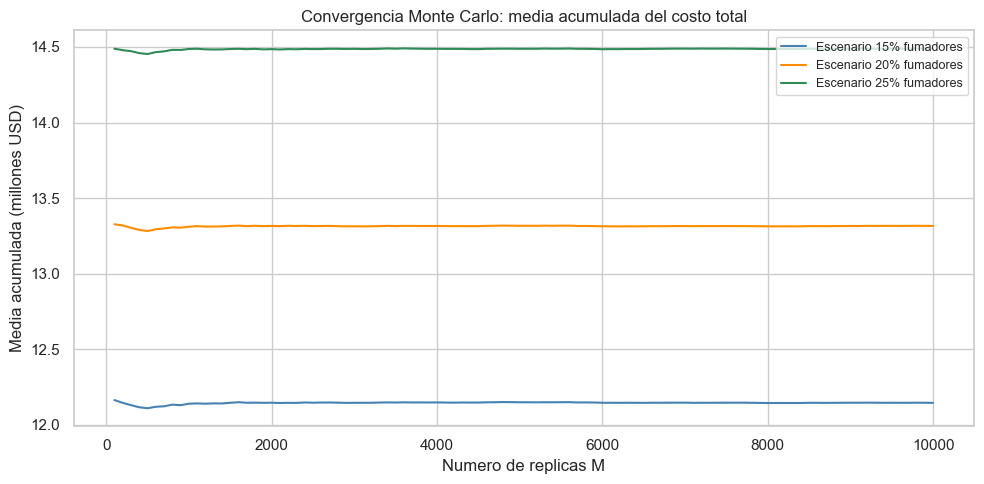

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
checkpoints_mc = np.arange(100, M + 1, 100)
colores_conv = ['steelblue', 'darkorange', 'seagreen']

for (nombre, costos), color in zip(resultados_mc.items(), colores_conv):
    medias_acum = [costos[:k].mean() / 1e6 for k in checkpoints_mc]
    ax.plot(checkpoints_mc, medias_acum, color=color, linewidth=1.5, label=nombre)

ax.set_title('Convergencia Monte Carlo: media acumulada del costo total', fontsize=12)
ax.set_xlabel('Numero de replicas M')
ax.set_ylabel('Media acumulada (millones USD)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_mc_convergencia.png', dpi=150, bbox_inches='tight')
plt.show()

### Resultados cuantitativos

In [16]:
costos_15 = resultados_mc['Escenario 15% fumadores']
costos_20 = resultados_mc['Escenario 20% fumadores']
costos_25 = resultados_mc['Escenario 25% fumadores']

media_15, media_20, media_25 = costos_15.mean(), costos_20.mean(), costos_25.mean()

diferencia_abs = media_25 - media_15
diferencia_pct = diferencia_abs / media_15 * 100

p5_15,  p95_15  = np.percentile(costos_15, [5, 95])
p5_20,  p95_20  = np.percentile(costos_20, [5, 95])
p5_25,  p95_25  = np.percentile(costos_25, [5, 95])

fumadores_adicionales = (0.25 - 0.15) * N
mu_fo,  s_fo  = params_log['fumador_obeso']
mu_fno, s_fno = params_log['fumador_no_obeso']
mu_nf,  s_nf  = params_log['no_fumador']
e_fum_mezcla = p_O_dado_F * np.exp(mu_fo  + s_fo**2/2) + \
               (1 - p_O_dado_F) * np.exp(mu_fno + s_fno**2/2)
e_no_fum     = np.exp(mu_nf + s_nf**2/2)
diferencia_mc_teorica = fumadores_adicionales * (e_fum_mezcla - e_no_fum)

print("=== RESULTADOS MONTE CARLO - CIFRAS CLAVE ===")
print(f"\nCosto total esperado (N={N:,} asegurados):")
print(f"  Escenario 15% fumadores : ${media_15:>15,.0f}")
print(f"  Escenario 20% fumadores : ${media_20:>15,.0f}")
print(f"  Escenario 25% fumadores : ${media_25:>15,.0f}")
print(f"\nDiferencia escenario 25% vs. 15%:")
print(f"  Absoluta    : ${diferencia_abs:>15,.0f}  ({diferencia_pct:.1f}%)")
print(f"  Por persona : ${diferencia_abs/N:>14,.0f}")
print(f"\nRango P5-P95:")
print(f"  15%: [${p5_15:,.0f} - ${p95_15:,.0f}]  amplitud = ${p95_15-p5_15:,.0f}")
print(f"  20%: [${p5_20:,.0f} - ${p95_20:,.0f}]  amplitud = ${p95_20-p5_20:,.0f}")
print(f"  25%: [${p5_25:,.0f} - ${p95_25:,.0f}]  amplitud = ${p95_25-p5_25:,.0f}")
print(f"\nPrediccion teorica (modelo log-normal, 100 fumadores extra):")
print(f"  E[diferencia] = 100 x (E[C|fum] - E[C|no fum]) = ${diferencia_mc_teorica:,.0f}")
print(f"  Diferencia MC observada                         = ${diferencia_abs:,.0f}")
print(f"  Cociente (MC / teorico)                         = {diferencia_abs / diferencia_mc_teorica:.3f}")

=== RESULTADOS MONTE CARLO - CIFRAS CLAVE ===

Costo total esperado (N=1,000 asegurados):
  Escenario 15% fumadores : $     12,145,384
  Escenario 20% fumadores : $     13,315,998
  Escenario 25% fumadores : $     14,488,601

Diferencia escenario 25% vs. 15%:
  Absoluta    : $      2,343,217  (19.3%)
  Por persona : $         2,343

Rango P5-P95:
  15%: [$11,556,815 - $12,754,703]  amplitud = $1,197,887
  20%: [$12,665,830 - $13,970,508]  amplitud = $1,304,677
  25%: [$13,792,193 - $15,177,358]  amplitud = $1,385,165

Prediccion teorica (modelo log-normal, 100 fumadores extra):
  E[diferencia] = 100 x (E[C|fum] - E[C|no fum]) = $2,341,343
  Diferencia MC observada                         = $2,343,217
  Cociente (MC / teorico)                         = 1.001


Los tres escenarios muestran una media acumulada visualmente estable antes de $M = 3000$, y con $M = 10.000$ el error Monte Carlo estándar de la media es pequeño frente al costo total esperado. Bajo el modelo simulado, pasar de 15% a 25% de fumadores aumenta el costo total esperado en ~\$2.34M (19.3%), lo que escala directamente desde la diferencia promedio estimada $\hat{\theta}_1 \approx \$23.640$ por fumador adicional. Los rangos P5–P95 son amplios (amplitud ~\$1.2–1.4M en los tres escenarios), reflejando la alta variabilidad intrínseca de los costos médicos: el costo esperado es predecible, pero el realizado no. La predicción teórica basada en los parámetros log-normal estimados coincide con el resultado Monte Carlo (cociente ≈ 1.0), lo que sugiere que la implementación es internamente consistente.

---
## Sección 4: Conclusiones

In [17]:
theta1_hat = resultado_theta1['θ̂ ($)']
theta2_hat = resultado_theta2['θ̂ ($)']
ic1_inf, ic1_sup = resultado_theta1['IC 95% inf. ($)'], resultado_theta1['IC 95% sup. ($)']
ic2_inf, ic2_sup = resultado_theta2['IC 95% inf. ($)'], resultado_theta2['IC 95% sup. ($)']
ic1_boot_inf, ic1_boot_sup = ic_theta1_boot
ic2_boot_inf, ic2_boot_sup = ic_theta2_boot

print("=== RESUMEN CONCLUSIONES ===")
print(f"\nθ1 (fumador vs no fumador):")
print(f"  θ̂1 = ${theta1_hat:,.2f}")
print(f"  IC Welch 95%    : [${ic1_inf:,.2f}, ${ic1_sup:,.2f}]")
print(f"  IC Bootstrap 95%: [${ic1_boot_inf:,.2f}, ${ic1_boot_sup:,.2f}]")

print(f"\nθ2 (fum. obeso vs. fum. no obeso):")
print(f"  θ̂2 = ${theta2_hat:,.2f}")
print(f"  IC Welch 95%    : [${ic2_inf:,.2f}, ${ic2_sup:,.2f}]")
print(f"  IC Bootstrap 95%: [${ic2_boot_inf:,.2f}, ${ic2_boot_sup:,.2f}]")

razon = theta2_hat / theta1_hat
print(f"\nRazon θ̂2/θ̂1 = {razon:.2f}  ->  la diferencia asociada a obesidad dentro de fumadores es "
      f"{razon*100:.0f}% de la diferencia fumador vs. no fumador")
print(f"\nDiferencia MC 25% vs 15% (N=1000): ${diferencia_abs:,.0f} ({diferencia_pct:.1f}%)")

=== RESUMEN CONCLUSIONES ===

θ1 (fumador vs no fumador):
  θ̂1 = $23,639.69
  IC Welch 95%    : [$22,216.58, $25,062.80]
  IC Bootstrap 95%: [$22,235.62, $25,082.42]

θ2 (fum. obeso vs. fum. no obeso):
  θ̂2 = $20,383.83
  IC Welch 95%    : [$19,090.84, $21,676.83]
  IC Bootstrap 95%: [$19,099.54, $21,671.27]

Razon θ̂2/θ̂1 = 0.86  ->  la diferencia asociada a obesidad dentro de fumadores es 86% de la diferencia fumador vs. no fumador

Diferencia MC 25% vs 15% (N=1000): $2,343,217 (19.3%)


Los resultados entregan evidencia compatible con ambos componentes de la hipótesis descriptiva del Lab 1. El estimador $\hat{\theta}_1 = \$23.640$ (IC 95% Welch: [\$22.217, \$25.063]; bootstrap: [\$22.236, \$25.082]) muestra que el grupo de fumadores presenta costos médicos promedio significativamente mayores que el grupo de no fumadores, con intervalos estrictamente positivos por ambos métodos. Dentro del grupo fumador, $\hat{\theta}_2 = \$20.384$ (IC 95%: [\$19.091, \$21.677]) cuantifica la diferencia promedio asociada a obesidad: los fumadores con BMI > 30 presentan, en promedio, \$20.384 más que los fumadores con BMI <= 30, el 86% de la diferencia fumador vs. no fumador. Esta magnitud sugiere heterogeneidad relevante entre subgrupos de fumadores, aunque no debe interpretarse como prueba formal de interacción no lineal entre fumar y obesidad. La simulación Monte Carlo traslada estas diferencias promedio a escala de cartera: bajo el modelo propuesto, una cartera de 1000 asegurados tendría un costo esperado ~\$2.34M mayor al pasar de 15% a 25% de fumadores, con un rango de incertidumbre P5–P95 que debe incorporarse en las reservas de capital.